# Table of Contents

1. [Project Overview](#Project-Overview)
2. [Dataset](#dataset)
3. [Model Architecture (From Scratch)](#Model-Architecture-From-Scratch)
4. [Baseline Implementation](#Baseline-Implementation)
5. [Optimization Techniques](#Optimization-Techniques)
6. [Evaluation Metrics](#Evaluation-Metrics)
7. [Ablation Study](#Ablation-Study)
    - [Learning Rate Comparisons](#Learning-Rate-Comparisons)
    - [Regularization](#Regularization)
        - [Effect of Dropout Probability](#Effect-of-Dropout-Probability)
        - [Effect of L2 Regularization Strength](#Effect-of-L2-Regularization-Strength)
    - [Effect of Optimization Algorithm](#Effect-of-Optimization-Algorithm)
    - [Effect of Adam Hyperparameters](#Effect-of-Adam-Hyperparameters)
8. [Final Model Configuration](#Final-Model-Configuration)
9. [Results and Discussion](#Results-and-Discussion)
10. [Conclusion](#Conclusion)

## Project Overview

This project implements a neural network from scratch to classify CIFAR-10 images.  
The objective is to achieve at least 75% test accuracy.  

An ablation study is conducted to evaluate:
- Learning rate decay strategies  
- Regularization methods (L2, Dropout)  
- Optimization algorithms (SGD, Momentum, Adam)  
- Adam hyperparameter sensitivity  

## Dataset

In [3]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from util import get_device
from evaluations import train_model
from model.model import Model

In [4]:
# CIFAR-10 normalization stats
cifar_mean = [0.485, 0.456, 0.406]
cifar_std  = [0.229, 0.224, 0.225]


# Training transforms (with augmentation + normalization)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])


# Test transforms (NO augmentation, but WITH normalization)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])


training_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=train_transform
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=test_transform
)


from torch.utils.data import DataLoader
batch_size = 128
train_loader = torch.utils.data.DataLoader(training_data, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

### Data Format & Batch Creation

In [5]:
image, label = training_data[0]
print(image.shape)
print("Label: ", label)

print("All Class Labels: \n", training_data.classes)

for images, labels in train_loader:
    print("images: [batch_size, channels, height, width]")
    print(images.shape)
    print("labels: [batch_size]")
    print(labels.shape)

    break


torch.Size([3, 32, 32])
Label:  6
All Class Labels: 
 ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
images: [batch_size, channels, height, width]
torch.Size([128, 3, 32, 32])
labels: [batch_size]
torch.Size([128])


# Example images

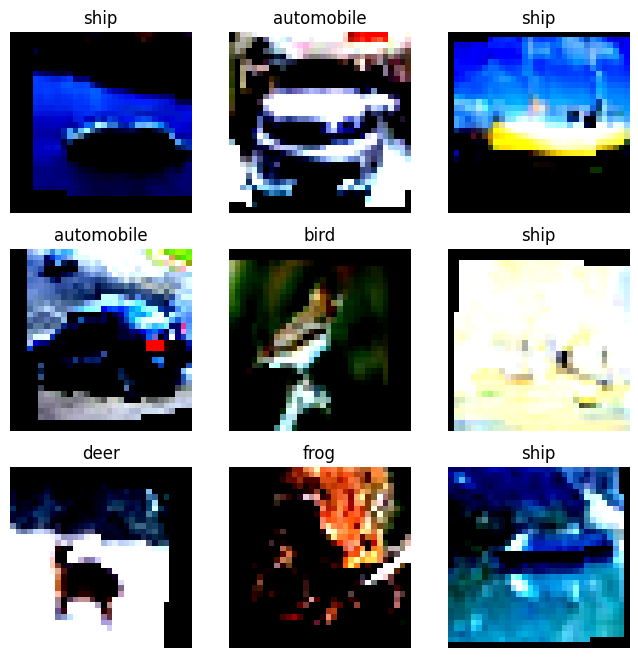

In [6]:
from util import show_random_images
show_random_images(training_data)


## Create model (Pytorch Implementation)

### Layer Creation

In [7]:
device = get_device()

NVIDIA CUDA detected
Set to use device: cuda


In [ ]:
main_model = Model()
train_model(
    model=main_model,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=20,
    lr=0.001,
    optimizer_type="adam",
    weight_decay=1e-4,
    learn_rate_type="cosine",
    gamma=0.9
)

Epoch 1: Loss 1.5609, Train 43.32%, Test 53.83%
Epoch 2: Loss 1.2825, Train 53.48%, Test 60.43%
Epoch 3: Loss 1.1733, Train 57.73%, Test 62.48%
Epoch 4: Loss 1.1006, Train 60.80%, Test 64.91%
Epoch 5: Loss 1.0492, Train 62.73%, Test 67.77%
Epoch 6: Loss 1.0103, Train 63.96%, Test 69.04%
Epoch 7: Loss 0.9805, Train 65.31%, Test 67.84%
Epoch 8: Loss 0.9467, Train 66.33%, Test 69.93%
Epoch 9: Loss 0.9199, Train 67.45%, Test 71.19%
Epoch 10: Loss 0.8940, Train 68.37%, Test 71.54%
Epoch 11: Loss 0.8763, Train 68.95%, Test 72.78%
Epoch 12: Loss 0.8559, Train 69.69%, Test 71.91%
Epoch 13: Loss 0.8390, Train 70.49%, Test 73.42%
Epoch 14: Loss 0.8179, Train 71.30%, Test 73.57%
Epoch 15: Loss 0.8101, Train 71.44%, Test 73.85%
Epoch 16: Loss 0.7950, Train 72.11%, Test 74.08%
Epoch 17: Loss 0.7816, Train 72.52%, Test 74.73%
Epoch 18: Loss 0.7743, Train 72.92%, Test 74.96%
Epoch 19: Loss 0.7722, Train 73.02%, Test 74.78%
Epoch 20: Loss 0.7703, Train 72.89%, Test 74.86%


([43.324,
  53.484,
  57.734,
  60.8,
  62.726,
  63.958,
  65.306,
  66.332,
  67.448,
  68.366,
  68.946,
  69.686,
  70.494,
  71.298,
  71.442,
  72.106,
  72.516,
  72.916,
  73.018,
  72.888],
 [53.83,
  60.42999999999999,
  62.480000000000004,
  64.91,
  67.77,
  69.04,
  67.84,
  69.93,
  71.19,
  71.54,
  72.78,
  71.91,
  73.42,
  73.57000000000001,
  73.85000000000001,
  74.08,
  74.72999999999999,
  74.96000000000001,
  74.78,
  74.86],
 [(0, 2.313518762588501),
  (1, 3.5333852767944336),
  (2, 3.0510263442993164),
  (3, 2.735691785812378),
  (4, 2.6349244117736816),
  (5, 2.486710548400879),
  (6, 2.4748878479003906),
  (7, 2.1945440769195557),
  (8, 2.319408416748047),
  (9, 2.188739776611328),
  (10, 1.9861195087432861),
  (11, 2.1065075397491455),
  (12, 2.018528699874878),
  (13, 2.060985565185547),
  (14, 2.1503677368164062),
  (15, 2.0000345706939697),
  (16, 2.0740976333618164),
  (17, 1.980607271194458),
  (18, 1.94125235080719),
  (19, 2.0611376762390137),
  (20, 

In [ ]:
# torch.save(model.state_dict(), "cifar10_model_adam_normalize.pth")

# Abalation Study

## Base Model

In [ ]:
base_model, base_train_accs, base_test_accs, base_train_costs = train_model(
    model=Model(),
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=5,
    lr=0.01,
    optimizer_type="sgd",
    weight_decay=0.0,
    learn_rate_type=None
)
print(f"Base Model Stats: \nTrain Accuracy (Per Epoch): {base_train_accs}\nTest Accuracy (Per Epoch): {base_test_accs} \nLoss Per Iteration: {base_train_costs}")

## Regularization

### L2 Regularization 

### Dropout

## Optimization Algorithms

### Cosine Decay

### Adam - Beta1 & Beta2